In [11]:
%pip install pandas


In [2]:


import pandas as pd
from rdkit import Chem

# Load your own CSV
df = pd.read_csv("LOTUS.csv")
df


,LOTUS ID,SMILES
0,LTS0257199,CO[C@H](C=C(C)C)C[C@@H](C)[C@H]1CC[C@@]2(C)[C@...
1,LTS0124597,CC(=O)OC1C(OC2C(OC3CC(O)CC4=CCC5C6CC7OC8(CCC(C...
2,LTS0121510,C[C@H](CO)[C@H]1OC(=O)C=C2C1=C[C@H]1OC(=O)[C@]...
3,LTS0110032,CS(=O)(=O)C=CCO
4,LTS0103990,COc1cccc2c1C(=O)O[C@H](CCC[C@H](C)O)C2
...,...,...
276513,LTS0059294,C=C1C[C@@H]2OC(=O)[C@H](C)[C@H]2[C@@H](O)/C=C(...
276514,LTS0083019,COC(=O)C1=CO[C@@H](O[C@@H]2O[C@H](CO)[C@@H](O)...
276515,LTS0117662,CCc1c(OC)oc(CCCCCCCCCC(C)O)c(C)c1=O
276516,LTS0137387,CC1=C(C)C2C(Cc3ccccc3)N=C(O)C23OC(=O)CCC(=O)CC...


In [3]:
# Checking for missing values in the dataset
df.isna().sum()

LOTUS ID    0
SMILES      0
dtype: int64

💊 **Lipinski’s Rule of Five**

Lipinski’s Rule of Five is a widely used guideline in drug discovery to evaluate the oral bioavailability of a compound. It helps identify molecules that are more likely to become orally active drugs in humans.

A compound is considered likely to have good oral bioavailability if **no more than one** of the following rules is violated:

- **Molecular weight** ≤ 500 Da  
- **LogP** (octanol–water partition coefficient) ≤ 5  
- **Hydrogen bond donors** (OH and NH groups) ≤ 5  
- **Hydrogen bond acceptors** (N and O atoms) ≤ 10  


In [4]:
# Converting SMILES strings into RDKit molecule objects
df['Mol'] = df['SMILES'].apply(Chem.MolFromSmiles)

# Checking for missing values (invalid SMILES will result in a 'None' or NaN in the 'Mol' column)
df.isna().sum()

# Removing rows where molecule conversion failed
df.dropna(inplace=True)
df.reset_index(inplace=True, drop=True)
df

,LOTUS ID,SMILES,Mol
0,LTS0257199,CO[C@H](C=C(C)C)C[C@@H](C)[C@H]1CC[C@@]2(C)[C@...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...
1,LTS0124597,CC(=O)OC1C(OC2C(OC3CC(O)CC4=CCC5C6CC7OC8(CCC(C...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...
2,LTS0121510,C[C@H](CO)[C@H]1OC(=O)C=C2C1=C[C@H]1OC(=O)[C@]...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...
3,LTS0110032,CS(=O)(=O)C=CCO,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...
4,LTS0103990,COc1cccc2c1C(=O)O[C@H](CCC[C@H](C)O)C2,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...
...,...,...,...
276513,LTS0059294,C=C1C[C@@H]2OC(=O)[C@H](C)[C@H]2[C@@H](O)/C=C(...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...
276514,LTS0083019,COC(=O)C1=CO[C@@H](O[C@@H]2O[C@H](CO)[C@@H](O)...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...
276515,LTS0117662,CCc1c(OC)oc(CCCCCCCCCC(C)O)c(C)c1=O,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...
276516,LTS0137387,CC1=C(C)C2C(Cc3ccccc3)N=C(O)C23OC(=O)CCC(=O)CC...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...


💊 **Lipinski’s Rule of Five**

Lipinski’s Rule of Five is a widely used guideline in drug discovery to evaluate the oral bioavailability of a compound. It helps identify molecules that are more likely to become orally active drugs in humans.

A compound is considered likely to have good oral bioavailability if **no more than one** of the following rules is violated:

- **Molecular weight** ≤ 500 Da  
- **LogP** (octanol–water partition coefficient) ≤ 5  
- **Hydrogen bond donors** (OH and NH groups) ≤ 5  
- **Hydrogen bond acceptors** (N and O atoms) ≤ 10  


In [5]:
from rdkit.Chem import Descriptors
from rdkit.Chem.Descriptors import rdMolDescriptors

# Calculating Molecular Weight for each molecule
df['MolWt'] = df['Mol'].apply(Descriptors.MolWt)
df

,LOTUS ID,SMILES,Mol,MolWt
0,LTS0257199,CO[C@H](C=C(C)C)C[C@@H](C)[C@H]1CC[C@@]2(C)[C@...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,632.879
1,LTS0124597,CC(=O)OC1C(OC2C(OC3CC(O)CC4=CCC5C6CC7OC8(CCC(C...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,897.065
2,LTS0121510,C[C@H](CO)[C@H]1OC(=O)C=C2C1=C[C@H]1OC(=O)[C@]...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,398.839
3,LTS0110032,CS(=O)(=O)C=CCO,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,136.172
4,LTS0103990,COc1cccc2c1C(=O)O[C@H](CCC[C@H](C)O)C2,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,264.321
...,...,...,...,...
276513,LTS0059294,C=C1C[C@@H]2OC(=O)[C@H](C)[C@H]2[C@@H](O)/C=C(...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,266.337
276514,LTS0083019,COC(=O)C1=CO[C@@H](O[C@@H]2O[C@H](CO)[C@@H](O)...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,422.383
276515,LTS0117662,CCc1c(OC)oc(CCCCCCCCCC(C)O)c(C)c1=O,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,338.488
276516,LTS0137387,CC1=C(C)C2C(Cc3ccccc3)N=C(O)C23OC(=O)CCC(=O)CC...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,479.617


In [6]:
# Calculating LogP (Partition Coefficient)
df['LogP'] = df['Mol'].apply(Descriptors.MolLogP)

# Counting Hydrogen Bond Donors
df['HbondDonors'] = df['Mol'].apply(Descriptors.NumHDonors)

# Counting Hydrogen Bond Acceptors
df['HbondAcceptors'] = df['Mol'].apply(Descriptors.NumHAcceptors)

# View the updated dataframe with all descriptor columns
df

,LOTUS ID,SMILES,Mol,MolWt,LogP,HbondDonors,HbondAcceptors
0,LTS0257199,CO[C@H](C=C(C)C)C[C@@H](C)[C@H]1CC[C@@]2(C)[C@...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,632.879,4.77290,4,8
1,LTS0124597,CC(=O)OC1C(OC2C(OC3CC(O)CC4=CCC5C6CC7OC8(CCC(C...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,897.065,1.42240,7,17
2,LTS0121510,C[C@H](CO)[C@H]1OC(=O)C=C2C1=C[C@H]1OC(=O)[C@]...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,398.839,0.30360,3,7
3,LTS0110032,CS(=O)(=O)C=CCO,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,136.172,-0.46300,1,3
4,LTS0103990,COc1cccc2c1C(=O)O[C@H](CCC[C@H](C)O)C2,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,264.321,2.32780,1,4
...,...,...,...,...,...,...,...
276513,LTS0059294,C=C1C[C@@H]2OC(=O)[C@H](C)[C@H]2[C@@H](O)/C=C(...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,266.337,1.57230,2,4
276514,LTS0083019,COC(=O)C1=CO[C@@H](O[C@@H]2O[C@H](CO)[C@@H](O)...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,422.383,-3.92100,7,12
276515,LTS0117662,CCc1c(OC)oc(CCCCCCCCCC(C)O)c(C)c1=O,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,338.488,4.56332,1,4
276516,LTS0137387,CC1=C(C)C2C(Cc3ccccc3)N=C(O)C23OC(=O)CCC(=O)CC...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,479.617,4.90870,2,5


In [12]:
# Filtering the dataframe based on Lipinski's Rule of Five
df_filtered = df[
    (df['MolWt'] <= 500) & 
    (df['LogP'] <= 5) & 
    (df['HbondDonors'] <= 5) & 
    (df['HbondAcceptors'] <= 10)
].copy()

# Resetting the index for the new filtered dataset
df_filtered.reset_index(inplace=True, drop=True)

# View the final prioritized compounds
df_filtered

,LOTUS ID,SMILES,Mol,MolWt,LogP,HbondDonors,HbondAcceptors
0,LTS0121510,C[C@H](CO)[C@H]1OC(=O)C=C2C1=C[C@H]1OC(=O)[C@]...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,398.839,0.30360,3,7
1,LTS0110032,CS(=O)(=O)C=CCO,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,136.172,-0.46300,1,3
2,LTS0103990,COc1cccc2c1C(=O)O[C@H](CCC[C@H](C)O)C2,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,264.321,2.32780,1,4
3,LTS0116501,CC1C(=O)OC2(C)C1C(=O)OC1CCN3CC=C(COC(=O)C2(C)O...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,365.382,-0.21190,1,8
4,LTS0256634,CC1=CC(=O)[C@H](O)[C@@]2(C)C[C@H]3OC(=O)C(C)=C...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,262.305,1.53450,1,4
...,...,...,...,...,...,...,...
142030,LTS0135917,CC(C)=CC(=O)/C=C(/C)CCC[C@@]1(C)OC(=O)[C@H](C(...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,414.498,4.50020,2,6
142031,LTS0183570,CCC(C)CCCCCC/C=C\CCC(=O)O,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,240.387,4.79410,1,1
142032,LTS0059294,C=C1C[C@@H]2OC(=O)[C@H](C)[C@H]2[C@@H](O)/C=C(...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,266.337,1.57230,2,4
142033,LTS0117662,CCc1c(OC)oc(CCCCCCCCCC(C)O)c(C)c1=O,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,338.488,4.56332,1,4


In [13]:
# Total compounds after cleaning
total_compounds = len(df)

# Compounds that passed Lipinski
passed = len(df_filtered)

# Compounds that failed Lipinski
failed = total_compounds - passed

print("Total:", total_compounds)
print("Passed:", passed)
print("Failed:", failed)


Total: 276518
Passed: 142035
Failed: 134483


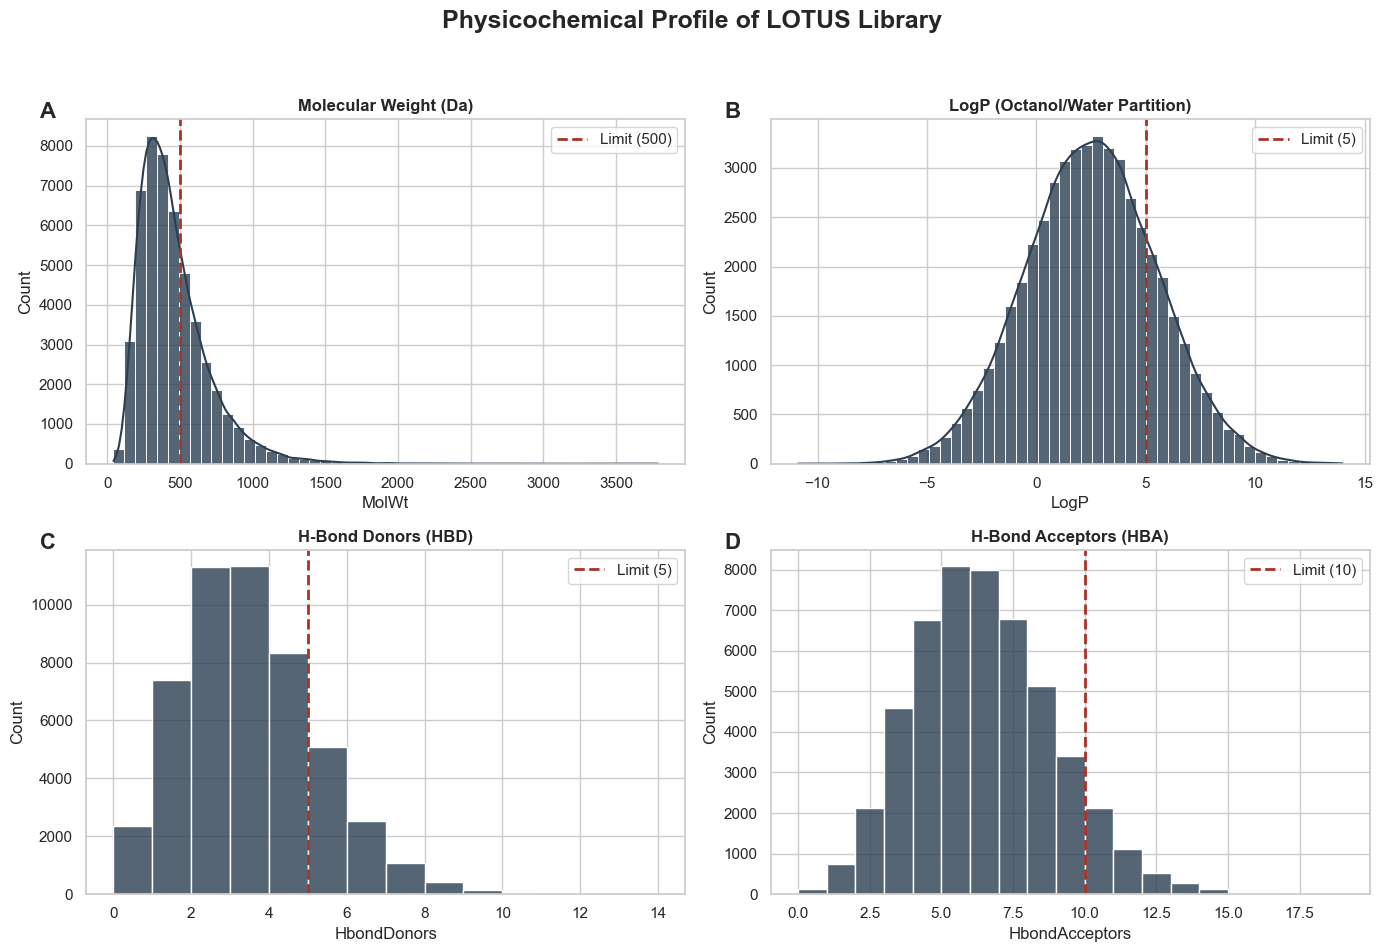

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure seaborn style is clean
sns.set_style("whitegrid")

# Set up a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten axes for easier iteration (from 2x2 array to 1D array)
ax_flat = axes.flatten()

# 1. Molecular Weight
sns.histplot(df['MolWt'], bins=50, ax=axes[0, 0], color='#2C3E50', kde=True, alpha=0.8)
axes[0, 0].axvline(500, color='#A93226', linestyle='--', linewidth=2, label='Limit (500)')

# 2. LogP
sns.histplot(df['LogP'], bins=50, ax=axes[0, 1], color='#2C3E50', kde=True, alpha=0.8)
axes[0, 1].axvline(5, color='#A93226', linestyle='--', linewidth=2, label='Limit (5)')

# 3. H-Bond Donors
sns.histplot(df['HbondDonors'], bins=range(0, 15), ax=axes[1, 0], color='#2C3E50', alpha=0.8)
axes[1, 0].axvline(5, color='#A93226', linestyle='--', linewidth=2, label='Limit (5)')

# 4. H-Bond Acceptors
sns.histplot(df['HbondAcceptors'], bins=range(0, 20), ax=axes[1, 1], color='#2C3E50', alpha=0.8)
axes[1, 1].axvline(10, color='#A93226', linestyle='--', linewidth=2, label='Limit (10)')

# Add panel labels (A, B, C, D) and titles
titles = ['Molecular Weight (Da)', 'LogP (Octanol/Water Partition)', 
          'H-Bond Donors (HBD)', 'H-Bond Acceptors (HBA)']

for i, ax in enumerate(ax_flat):
    # Add the A, B, C, D label in the top-left corner
    ax.text(-0.05, 1.05, chr(65 + i), transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='top', ha='right')
    
    # Set the title
    ax.set_title(titles[i], fontweight='bold', fontsize=12)
    ax.legend(loc='upper right')

# Global adjustments
fig.suptitle('Physicochemical Profile of LOTUS Library', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save and show
plt.savefig("LOTUS_Physicochemical_Dist_Labeled.png", dpi=300, bbox_inches='tight')
plt.show()

⚖️ **Quantitative Estimate of Drug-Likeness (QED)**

QED is a metric that quantifies how "drug-like" a molecule is by combining several important physicochemical properties into a single score. It outputs a value between **0 and 1**, where higher scores indicate better drug-likeness.

**Properties Considered in QED:**

- Molecular weight (MW)  
- LogP (lipophilicity)  
- Hydrogen bond donors (HBD) and acceptors (HBA)  
- Rotatable bonds  
- Aromatic ring count  
- Structural alerts  
- Topological polar surface area (TPSA)  

**QED Score Interpretation:**

| QED Score | Interpretation |
|-----------|----------------|
| 0.9 – 1.0 | Highly drug-like |
| 0.7 – 0.9 | Moderately drug-like |
| 0.4 – 0.7 | Potentially drug-like |
| < 0.4     | Poor drug-likeness |

> **Note:** Most marketed oral drugs tend to have QED scores above 0.67, though this is a guideline rather than a strict cutoff. QED is especially useful for **ranking and prioritizing compounds** rather than just binary filtering.


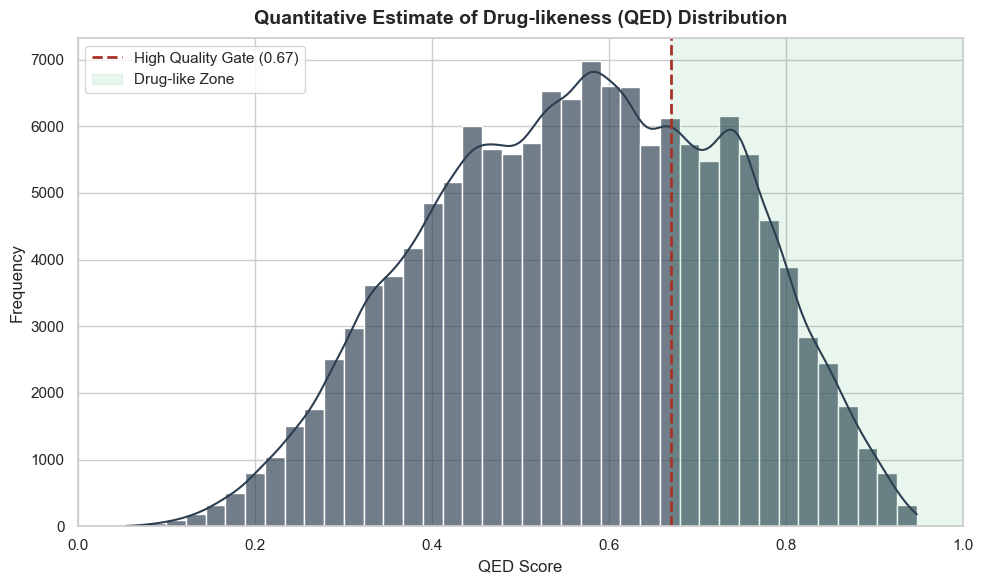

Mean QED: 0.568
Compounds with QED >= 0.67: 43402


In [20]:
import seaborn as sns

import matplotlib.pyplot as plt



# 1. Calculation (Make sure this runs first)

from rdkit.Chem import QED

df_filtered['Qed'] = df_filtered['Mol'].apply(QED.qed)



# 2. Plotting

plt.figure(figsize=(10, 6))



# Histogram with Kernel Density Estimate

sns.histplot(df_filtered['Qed'], bins=40, kde=True, color='#2C3E50', alpha=0.67)



# Add the "Drug-likeness" threshold line

plt.axvline(0.67, color='#A93226', linestyle='--', linewidth=2, label='High Quality Gate (0.67)')



# Fill the "High Quality" area to make it stand out

plt.axvspan(0.67, 1.0, alpha=0.1, color='#27AE60', label='Drug-like Zone')



# 3. Formatting to match your previous style

plt.title('Quantitative Estimate of Drug-likeness (QED) Distribution', 

          fontsize=14, fontweight='bold', pad=10)

plt.xlabel('QED Score', fontsize=12)

plt.ylabel('Frequency', fontsize=12)

plt.xlim(0, 1) # QED is always between 0 and 1

plt.legend(frameon=True, loc='upper left')



plt.tight_layout()

plt.savefig("LOTUS_QED_Distribution.png", dpi=300, bbox_inches='tight')

plt.show()



# Print summary statistics for your report

print(f"Mean QED: {df_filtered['Qed'].mean():.3f}")

print(f"Compounds with QED >= 0.67: {len(df_filtered[df_filtered['Qed'] >= 0.67])}")

In [21]:
# Filtering for highly drug-like compounds (QED >= 0.67) from the Lipinski-filtered set
df_filtered_qed = df_filtered[df_filtered['Qed'] >= 0.67].copy()

# Reset index for cleanliness
df_filtered_qed.reset_index(inplace=True, drop=True)

# View the highly drug-like compounds
df_filtered_qed


,LOTUS ID,SMILES,Mol,MolWt,LogP,HbondDonors,HbondAcceptors,Qed
0,LTS0103990,COc1cccc2c1C(=O)O[C@H](CCC[C@H](C)O)C2,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,264.321,2.3278,1,4,0.829236
1,LTS0256634,CC1=CC(=O)[C@H](O)[C@@]2(C)C[C@H]3OC(=O)C(C)=C...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,262.305,1.5345,1,4,0.672466
2,LTS0047914,CC1(C)C[C@@H]2C(=O)[C@@H]3C[C@H]3[C@](C)(O)CC[...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,222.328,2.3987,1,2,0.683071
3,LTS0120809,COc1cc2c(c(O)c1C(=O)C[C@H](O)c1ccccc1)C=CC(C)(...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,354.402,3.8914,2,5,0.796829
4,LTS0256604,O=C/C=C/c1ccc2c(c1)[C@H](CO)[C@@H](c1ccc(O)cc1)O2,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,296.322,2.8139,2,4,0.672307
...,...,...,...,...,...,...,...,...
43397,LTS0222270,C=C1CCC=C(C)CC(O)C(C(C)C)=CC=C(C)CCC1O,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,304.474,4.7035,2,2,0.689125
43398,LTS0061693,C=C(CO)C1CCC(C)C2CCC(C(=O)O)=CC12,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,250.338,2.6182,2,2,0.756955
43399,LTS0128667,C/C=C1/CN(C)[C@H]2Cc3c([nH]c4ccccc34)C(=O)C[C@...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,338.407,2.8741,2,3,0.784341
43400,LTS0197696,O=C(O)C1CCc2[nH]c3ccccc3c2C1,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,215.252,2.3574,2,1,0.766816


🧪 **Synthetic Accessibility (SA) Score**

The Synthetic Accessibility (SA) Score estimates how easy or difficult it would be to chemically synthesize a compound in the laboratory. It is a vital metric in drug discovery for prioritizing molecules that are not only active but also practical to manufacture.

**How It Works:**

The SA score combines two main components:

- **Fragment contributions** — How common or rare molecular fragments are based on a large dataset of known synthetic compounds.  
- **Complexity penalties** — Structural features that increase synthetic difficulty, such as:
  - Large ring systems  
  - Highly branched structures  
  - Chiral centers  
  - Unusual functional groups  

**SA Score Range and Interpretation:**

| SA Score | Interpretation |
|----------|----------------|
| 1.0 – 3.0 | Easy to synthesize |
| 3.1 – 5.0 | Moderate difficulty |
| 5.1 – 10.0 | Difficult to synthesize |

> **Note:** Lower SA scores are more desirable, indicating a higher likelihood that a compound can be successfully synthesized in the lab. Using the SA score helps avoid “dead-end” compounds early in the drug discovery pipeline.


In [22]:
import sascorer  # SA_Score.py you downloaded


In [23]:
import sascorer
print(sascorer.__file__)


c:\Users\HP\Desktop\Chemoinformatics\GROUP7 EMT CADDA\sascorer.py


In [26]:
import urllib.request

# URLs from RDKit GitHub
sascorer_url = "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py"
fpscores_url = "https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz"

# Download files into your current working directory
urllib.request.urlretrieve(sascorer_url, "sascorer.py")
urllib.request.urlretrieve(fpscores_url, "fpscores.pkl.gz")

print("Download complete ✅")


Download complete ✅


Calculating SA Scores... please wait.
Calculation complete! Generating plot...


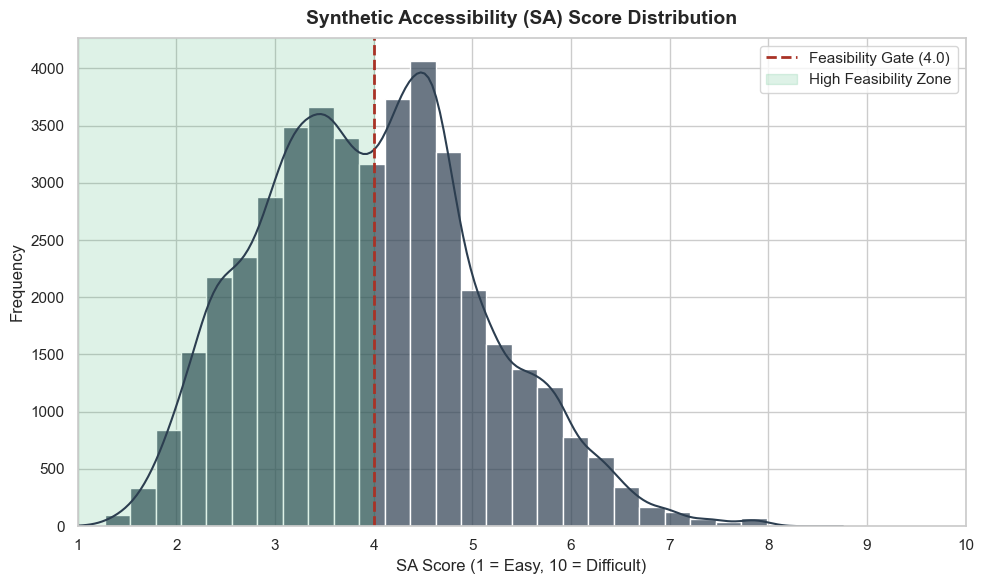

Mean SA Score: 3.96
Final Count (SA <= 4.0): 22,501 compounds


In [27]:
import sascorer
import seaborn as sns
import matplotlib.pyplot as plt

# 1. THE MISSING STEP: Run the calculation to create the 'sascore' column
# This might take a few seconds depending on the size of your dataset
print("Calculating SA Scores... please wait.")
df_filtered_qed['sascore'] = df_filtered_qed['Mol'].apply(sascorer.calculateScore)
print("Calculation complete! Generating plot...")

# 2. Setup the Plot
plt.figure(figsize=(10, 6))

# Histogram with KDE
sns.histplot(df_filtered_qed['sascore'], bins=30, kde=True, color='#2C3E50', alpha=0.7)

# Add the "Synthetically Feasible" threshold line (4.0)
plt.axvline(4.0, color='#A93226', linestyle='--', linewidth=2, label='Feasibility Gate (4.0)')

# Fill the "Easy to Synthesize" area (1.0 to 4.0)
plt.axvspan(1.0, 4.0, alpha=0.15, color='#27AE60', label='High Feasibility Zone')

# 3. Professional Formatting
plt.title('Synthetic Accessibility (SA) Score Distribution', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('SA Score (1 = Easy, 10 = Difficult)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(1, 10) 
plt.legend(frameon=True, loc='upper right')

plt.tight_layout()
plt.show()

# 4. Summary for your report text
easy_to_synth = len(df_filtered_qed[df_filtered_qed['sascore'] <= 4.0])
print(f"Mean SA Score: {df_filtered_qed['sascore'].mean():.2f}")
print(f"Final Count (SA <= 4.0): {easy_to_synth:,} compounds")

In [28]:
# Filtering QED-passed molecules with acceptable synthetic accessibility (SA ≤ 4)
df_filtered_sascore = df_filtered_qed[df_filtered_qed['sascore'] <= 4.0].copy()

# Reset index for cleanliness
df_filtered_sascore.reset_index(drop=True, inplace=True)

# Display the final filtered compounds
df_filtered_sascore


,LOTUS ID,SMILES,Mol,MolWt,LogP,HbondDonors,HbondAcceptors,Qed,sascore
0,LTS0103990,COc1cccc2c1C(=O)O[C@H](CCC[C@H](C)O)C2,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,264.321,2.32780,1,4,0.829236,3.114003
1,LTS0120809,COc1cc2c(c(O)c1C(=O)C[C@H](O)c1ccccc1)C=CC(C)(...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,354.402,3.89140,2,5,0.796829,3.150983
2,LTS0256604,O=C/C=C/c1ccc2c(c1)[C@H](CO)[C@@H](c1ccc(O)cc1)O2,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,296.322,2.81390,2,4,0.672307,3.353476
3,LTS0263062,COc1cc(CC2COCC2C(O)c2ccc(O)c(OC)c2)ccc1O,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,360.406,2.65370,3,6,0.733984,3.511843
4,LTS0047827,COc1cc2c(c(OC)c1OC)-c1c(cc3c(c1OC)OCO3)CC(C)(O...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C2...,416.470,3.60240,1,7,0.816107,3.615909
...,...,...,...,...,...,...,...,...,...
22496,LTS0045147,Cc1ccc2c(c1)C(O)C(C)CC2=O,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,190.242,2.25092,1,2,0.680899,3.103911
22497,LTS0128602,COc1cc2c(cc1O)C(Cc1ccc3c(c1)OCO3)N(C)CC2,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,327.380,2.90120,1,5,0.939285,2.843807
22498,LTS0058158,COc1ccc(C2CC(=O)c3cc(OC)c4c(c3O2)C=CC(C)(C)O4)...,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,396.439,4.60310,0,6,0.752481,3.234652
22499,LTS0215144,COc1ccc(-c2oc3c(OC)c(OC)c(OC)c(O)c3c(=O)c2OC)cc1,<rdkit.Chem.rdchem.Mol object at 0x0000015C6C6...,388.372,3.20860,1,8,0.687634,2.471882


In [29]:
from rdkit import Chem
from rdkit.Chem import FilterCatalog


In [30]:
# Build PAINS catalog (Baell & Holloway, JMC 2010)
params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog.FilterCatalog(params)


In [31]:
pains_flags = []
pains_hits = []

for smi in df_filtered_sascore['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    
    if mol is None:
        pains_flags.append(None)
        pains_hits.append(None)
    else:
        matches = pains_catalog.GetMatches(mol)
        pains_flags.append(len(matches) > 0)
        pains_hits.append("; ".join([m.GetDescription() for m in matches]))


In [32]:
df_filtered_sascore['PAINS_flag'] = pains_flags
df_filtered_sascore['PAINS_alerts'] = pains_hits


In [33]:
df_pains_free = df_filtered_sascore[df_filtered_sascore['PAINS_flag'] == False].copy()
df_pains_free.reset_index(drop=True, inplace=True)


In [34]:
df_pains_flagged = df_filtered_sascore[df_filtered_sascore['PAINS_flag'] == True].copy()
df_pains_flagged.reset_index(drop=True, inplace=True)


In [35]:
df_filtered_sascore[['SMILES', 'PAINS_flag', 'PAINS_alerts']].head(10)


,SMILES,PAINS_flag,PAINS_alerts
0,COc1cccc2c1C(=O)O[C@H](CCC[C@H](C)O)C2,False,
1,COc1cc2c(c(O)c1C(=O)C[C@H](O)c1ccccc1)C=CC(C)(...,False,
2,O=C/C=C/c1ccc2c(c1)[C@H](CO)[C@@H](c1ccc(O)cc1)O2,False,
3,COc1cc(CC2COCC2C(O)c2ccc(O)c(OC)c2)ccc1O,False,
4,COc1cc2c(c(OC)c1OC)-c1c(cc3c(c1OC)OCO3)CC(C)(O...,False,
5,COc1c(C=O)c(O)cc2c1CO[C@@H](C)C2,False,
6,COc1cccc2c1C(=O)C([C@@H](C)O)=C(CC(C)=O)C2=O,True,quinone_A(370)
7,CC1(C)C=Cc2cc(OC3OC(CO)C(O)C3O)ccc2O1,False,
8,CCCCC1=CC(=O)C(CC(=O)O)O1,False,
9,COc1cc(OC)c(OC)c(O)c1CCC(=O)c1ccccc1,False,


In [36]:
df_filtered_sascore['PAINS_flag'].value_counts()


PAINS_flag
False    20281
True      2220
Name: count, dtype: int64

In [37]:
df_pains_only = df_filtered_sascore[
    df_filtered_sascore['PAINS_flag'] == True
]

pains_counts = (
    df_pains_only['PAINS_alerts']
    .str.split('; ')
    .explode()
    .value_counts()
)

pains_counts.head(10)


PAINS_alerts
quinone_A(370)        1163
catechol_A(92)         404
indol_3yl_alk(461)     240
imine_one_A(321)       186
quinone_D(2)           156
mannich_A(296)         123
keto_keto_gamma(5)      55
ene_one_D(1)            48
anil_di_alk_C(246)      25
ene_one_hal(17)         17
Name: count, dtype: int64

In [38]:
df_pains_only[
    ['SMILES', 'PAINS_alerts']
].head(10)


,SMILES,PAINS_alerts
6,COc1cccc2c1C(=O)C([C@@H](C)O)=C(CC(C)=O)C2=O,quinone_A(370)
12,OCC1=C[C@H]2CC[C@H]3c4[nH]c5ccccc5c4CCN3[C@@H]...,indol_3yl_alk(461)
25,COc1cc2c(cc1OC)-c1c(OC)c(OC)cc3c1C(=NCC3)C2=O,quinone_D(2)
32,CC(C)C1=C(O)C(=O)C2=C(C=C3C(C)(C)CCC[C@@]32C)C1=O,quinone_A(370)
35,COc1cc2c(c(O)c1O)C(=O)c1c(OC)cc(C)c(OC)c1C2=O,quinone_A(370); catechol_A(92)
62,COc1cc2c(cc1O)C1Cc3ccc(OC)c(O)c3CN1CC2,mannich_A(296)
63,O=C1C[C@@H](O)[C@H](C2=CC(=O)c3c(O)cccc3C2=O)O1,quinone_A(370); ene_one_D(1)
68,COc1cc2c(cc1O)N[C@H](OC)[C@@H]1C[C@H](O)CN1C2=O,anil_di_alk_C(246)
90,COc1cc(O)c2c(c1)C(=O)c1cc(C)c(OS(=O)(=O)O)cc1C2=O,quinone_A(370)
97,COc1ccc2c(c1O)CN1CCc3cc4c(cc3C1C2)OCO4,mannich_A(296)


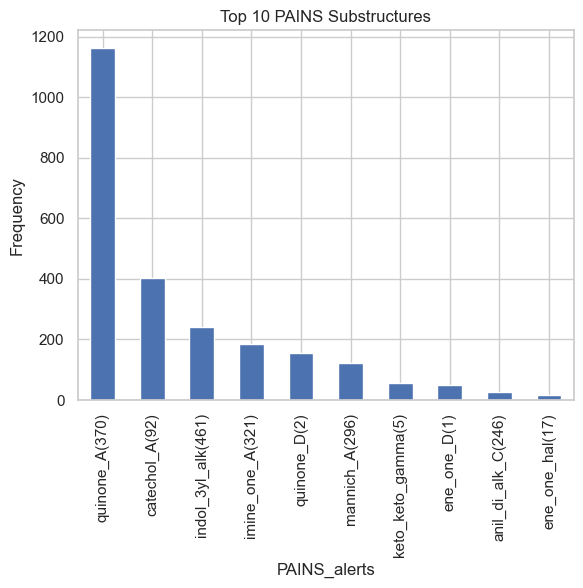

In [39]:
import matplotlib.pyplot as plt

pains_counts.head(10).plot(kind='bar')
plt.ylabel("Frequency")
plt.title("Top 10 PAINS Substructures")
plt.show()


In [40]:
# Filter only PAINS-free compounds:
df_hits = df_filtered_sascore[df_filtered_sascore['PAINS_flag'] == False].copy()
df_hits.reset_index(drop=True, inplace=True)


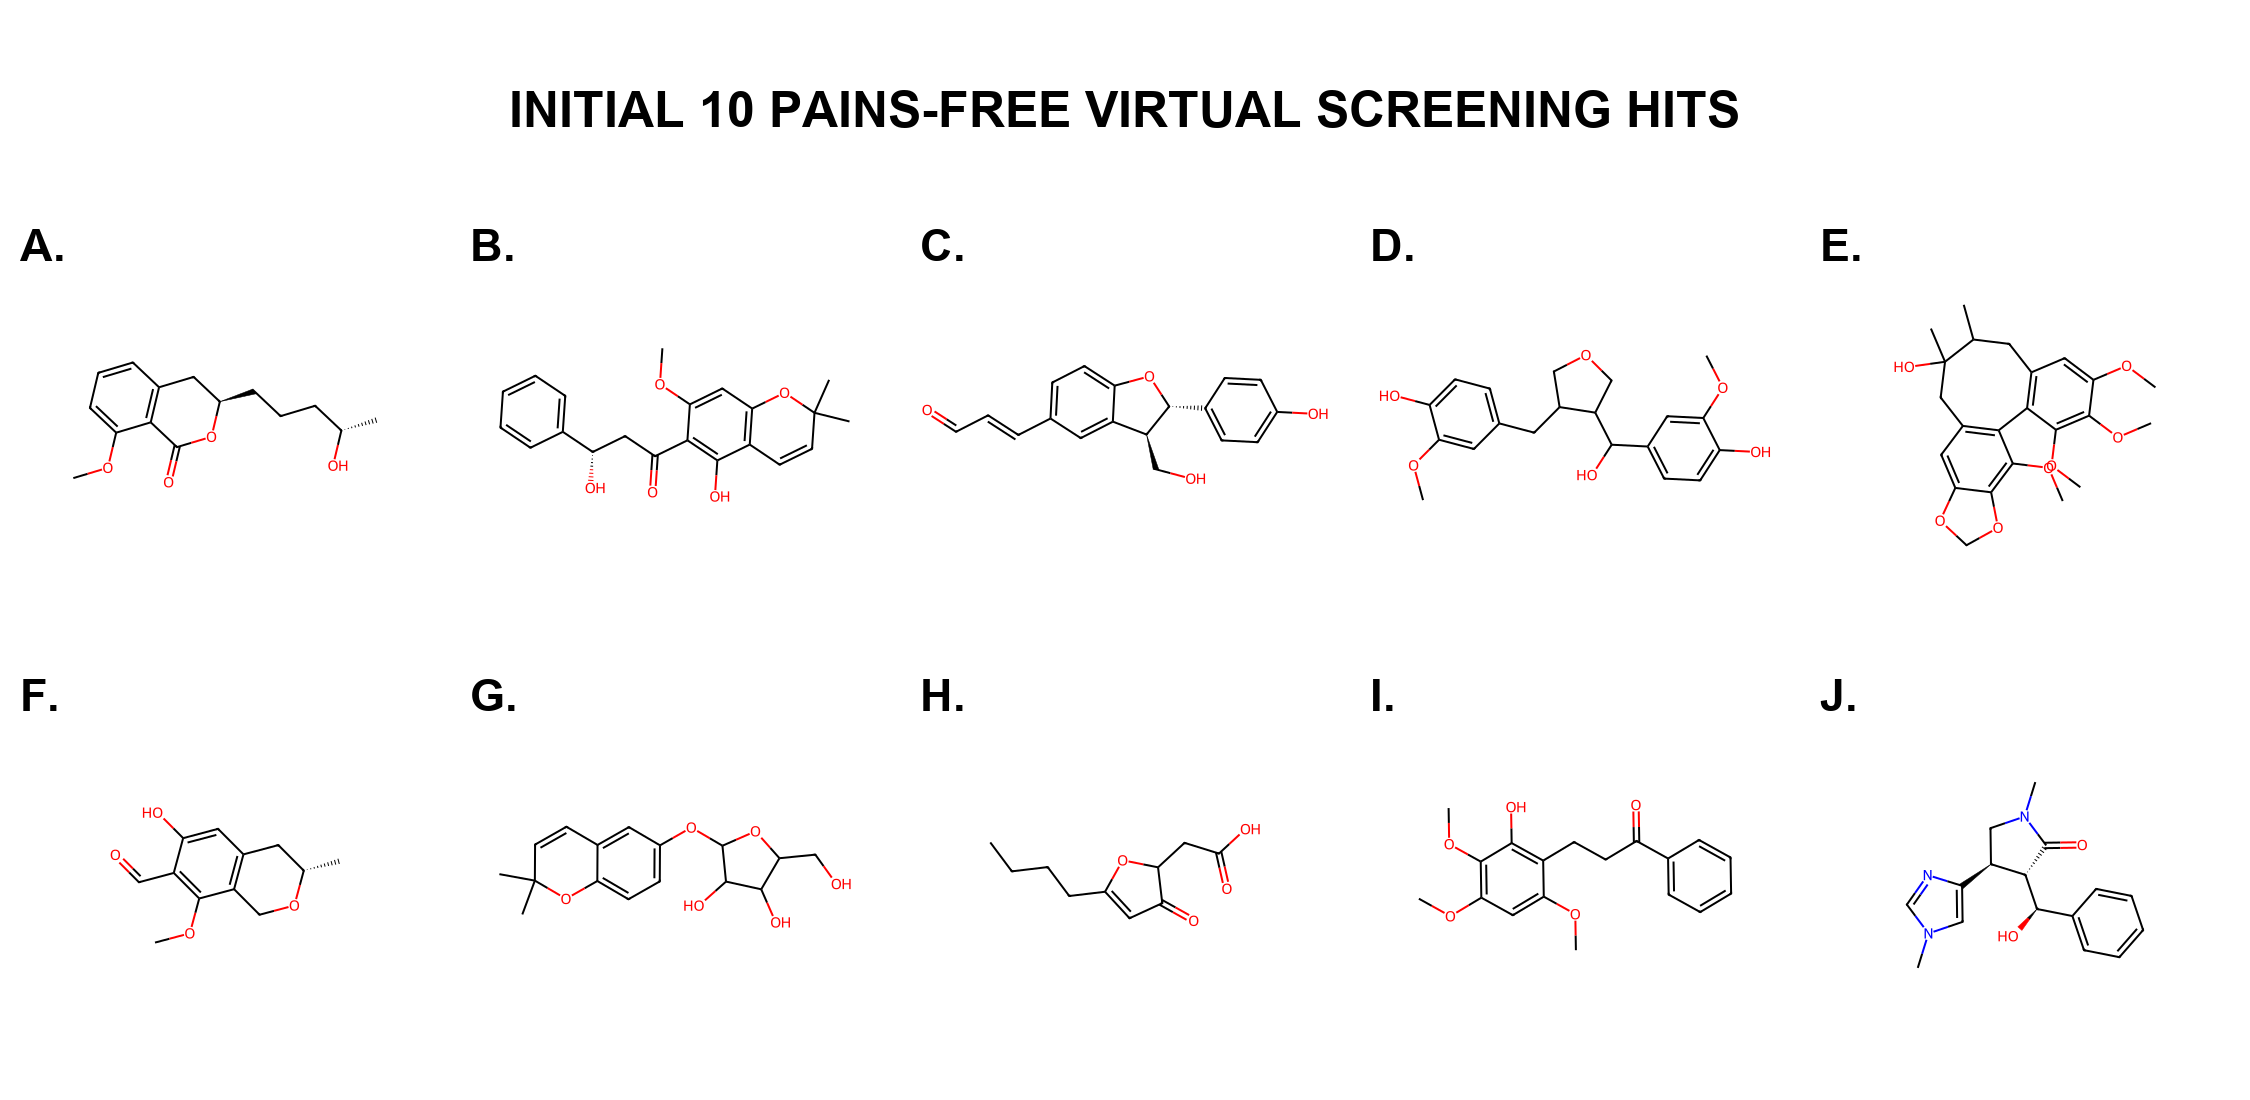

In [42]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont
import textwrap

# 1. Grab the first 10 molecules UNRANKED (Exactly as they appear in df_hits)
df_top_10 = df_hits.head(10).reset_index(drop=True)

# 2. Prepare the molecules
mols = [row['Mol'] for _, row in df_top_10.iterrows() if row['Mol'] is not None]

# 3. Generate the high-resolution grid WITHOUT legends
grid_hits = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(450, 450),
    legends=["" for _ in mols], 
    returnPNG=False
)

# 4. Setup White Header Space
width, height = grid_hits.size
header_h = 200
final_img = Image.new("RGB", (width, height + header_h), "white")
final_img.paste(grid_hits, (0, header_h))

draw = ImageDraw.Draw(final_img)

# 5. Define Fonts
try:
    font_title = ImageFont.truetype("arialbd.ttf", 50)
    font_label = ImageFont.truetype("arialbd.ttf", 45)
except:
    font_title = ImageFont.load_default()
    font_label = ImageFont.load_default()

# 6. Add A–J Labels to each grid cell
labels = list("ABCDEFGHIJ")
for i in range(len(mols)):
    row, col = i // 5, i % 5
    x = col * 450 + 20
    # Adjusted y to account for header
    y = row * 450 + header_h + 20
    draw.text((x, y), f"{labels[i]}.", fill="black", font=font_label)

# 7. Add Professional Main Title (Updated to reflect "Initial Hits")
main_title = "INITIAL 10 PAINS-FREE VIRTUAL SCREENING HITS"
wrapped_title = textwrap.fill(main_title, width=60)

bbox = draw.multiline_textbbox((0, 0), wrapped_title, font=font_title, align="center")
t_w, t_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
draw.multiline_text(((width - t_w) // 2, (header_h - t_h) // 2), 
                    wrapped_title, fill="black", font=font_title, align="center")

# 8. Final display
display(final_img)

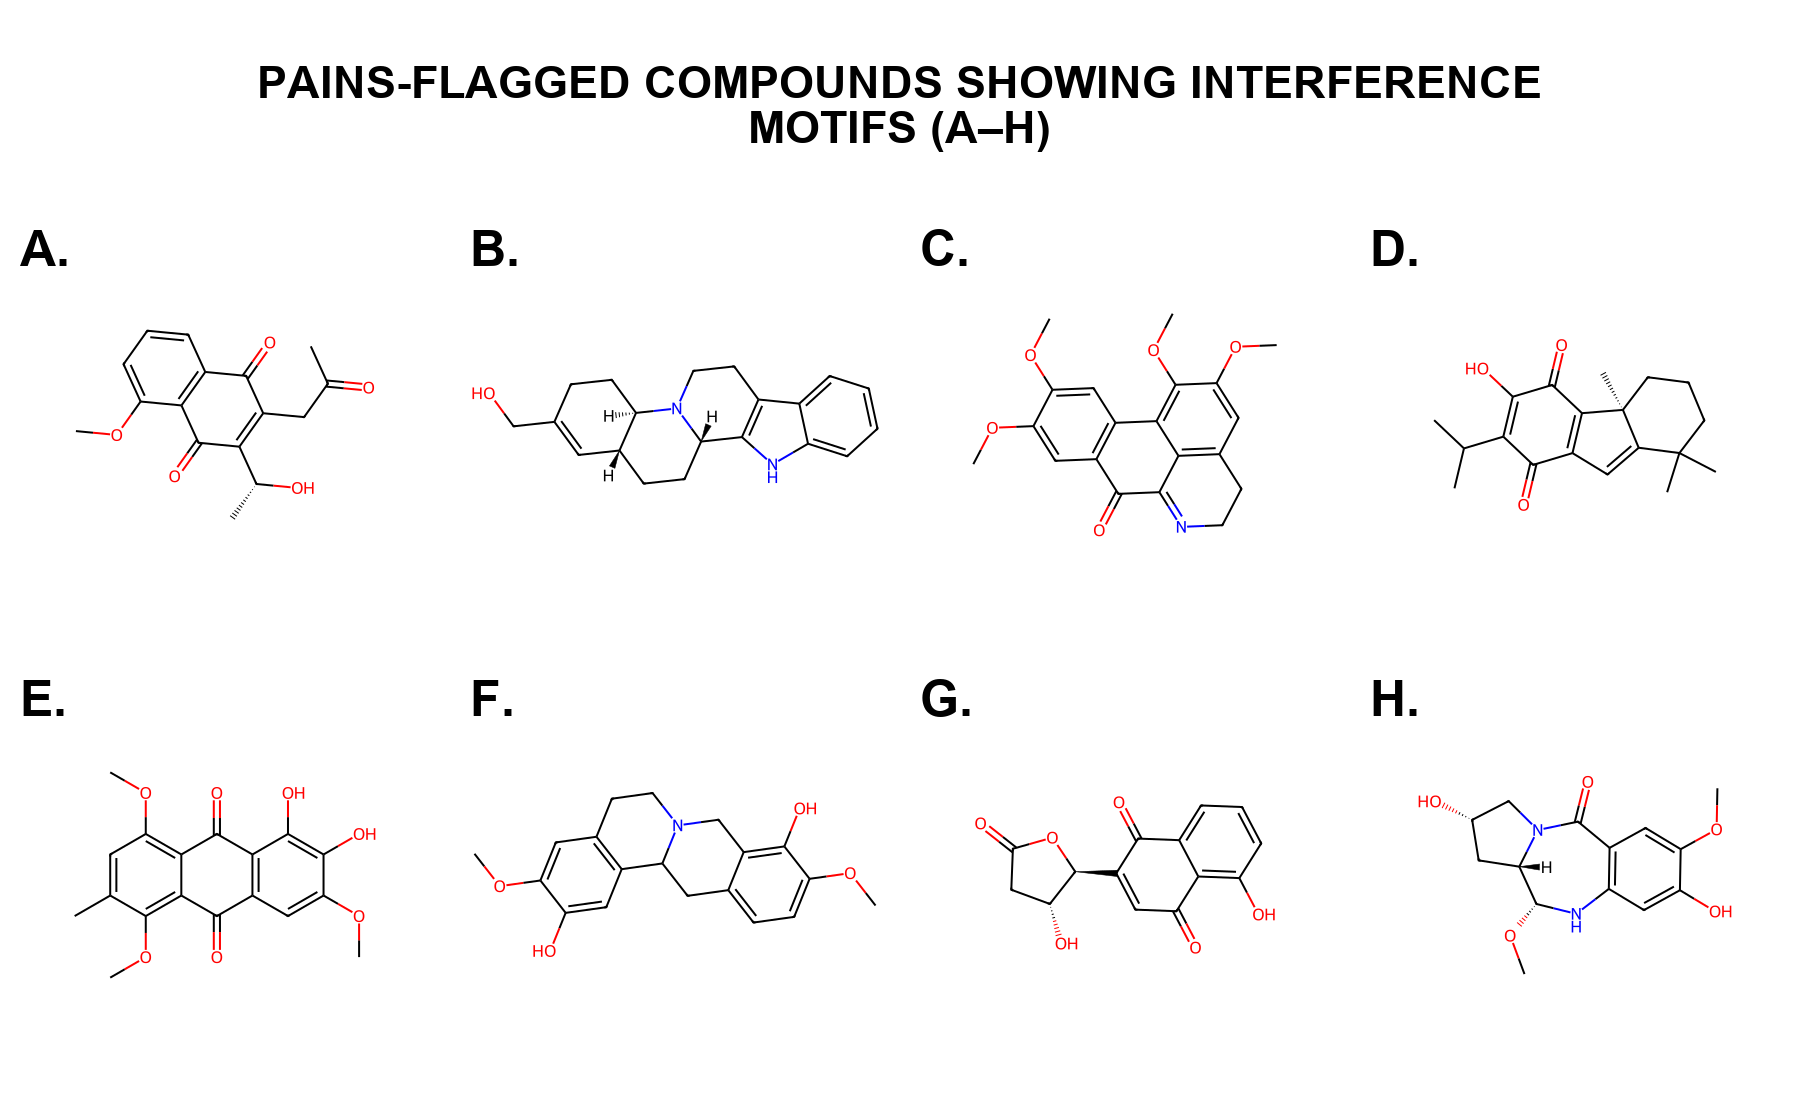

In [44]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import textwrap
from IPython.display import display

# 1. Prepare the molecules (Top 8 for a 2x4 grid)
top_pains = df_pains_only.head(8) 
mols = [Chem.MolFromSmiles(row['SMILES']) for _, row in top_pains.iterrows()]
mols = [m for m in mols if m is not None]

# 2. Generate Grid WITHOUT legends (Keeps the space under molecules clean)
grid_img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(450, 450),
    legends=["" for _ in mols], 
    returnPNG=False
)

# 3. Setup Header Space
width, height = grid_img.size
header_h = 200 
final_img = Image.new("RGB", (width, height + header_h), "white")
final_img.paste(grid_img, (0, header_h))

draw = ImageDraw.Draw(final_img)

# 4. Define Fonts
try:
    font_title = ImageFont.truetype("arialbd.ttf", 45) 
    font_label = ImageFont.truetype("arialbd.ttf", 50) 
except:
    font_title = ImageFont.load_default()
    font_label = ImageFont.load_default()

# 5. Add A–H Labels inside the grid cells
labels = list("ABCDEFGH")
for i in range(len(mols)):
    row, col = i // 4, i % 4
    x = col * 450 + 20
    y = row * 450 + header_h + 20
    draw.text((x, y), f"{labels[i]}.", fill="black", font=font_label)

# 6. Center the Main Title in the Header
main_title = "PAINS-FLAGGED COMPOUNDS SHOWING INTERFERENCE MOTIFS (A–H)"
wrapped_title = textwrap.fill(main_title, width=50)

bbox = draw.multiline_textbbox((0, 0), wrapped_title, font=font_title, align="center")
t_w, t_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
draw.multiline_text(((width - t_w) // 2, (header_h - t_h) // 2), 
                    wrapped_title, fill="black", font=font_title, align="center")


# 7. FINAL DISPLAY (Directly in VS Code output)
display(final_img)

In [57]:
print("Total compounds after SA filter:", len(df_filtered_sascore))
print("PAINS-free compounds:", len(df_hits))
print("PAINS-flagged compounds:", len(df_pains_flagged))


Total compounds after SA filter: 22501
PAINS-free compounds: 20281
PAINS-flagged compounds: 2220


In [58]:
# Select only required columns
df_export = df_hits_sorted[['LOTUS ID', 'SMILES']].copy()

# Export to CSV
df_export.to_csv("Final_PAINS_Free_ID_SMILES.csv", index=False)

print("CSV exported successfully ✅")


CSV exported successfully ✅
